In [1]:
from CompareCountries import CompareCountries
from MisallocationAnalysis import MisallocationAnalysis

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["cmr10", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,   # use ASCII hyphen instead of Unicode minus
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

In [3]:
spain = MisallocationAnalysis('Spain', start = 2000, end= 2007, sector='C')
spain2 = MisallocationAnalysis('Spain', start = 2014, end= 2020, sector='C')
compare = CompareCountries([spain,spain2])



In [4]:
compare.compare_all_moments()

,Spain 2000-2007,Spain 2014-2020
Std.dev.(log Z_pow),2.060,2.070
Std.dev.(log k),1.920,1.760
Std.dev.(log l),1.640,1.600
Top 20% Share of l,0.820,0.820
Top 20% Share of k,0.870,0.880
Coef log_Z on capital growth,0.062,0.028
Coef log_a on capital growth,0.029,0.036
Coef log_k on capital growth,-1.116,-0.891
Coef log_Z on capital growth t_0 - T,0.050,0.030
Coef log_a on capital growth t_0 - T,0.036,0.038


In [8]:
(spain.tfpdf.loc[2012,'log_tfp'] - spain.tfpdf.loc[2000,'log_tfp']) / spain.tfpdf.loc[2000,'log_tfp']

-0.1546557895777073

In [4]:
#descriptive statistics
os = compare.overview_statistics()
#descriptive statistics
ds = compare.descriptive_statistics()

In [11]:
ds

,Variables,Country,Period,Sector,count,mean,std,min,25%,50%,75%,max
0,assets,Spain,2000-2012,Manufacturing,358528.0,4122.38,40568.95,0.01,170.00,522.97,1959.86,6802434.00
1,revenue,Spain,2000-2012,Manufacturing,358528.0,10294.40,145239.29,0.10,386.27,1087.68,3873.74,22337286.06
2,materials,Spain,2000-2012,Manufacturing,358528.0,6398.31,108321.29,0.00,133.18,465.73,1982.67,17675381.03
3,wagebill,Spain,2000-2012,Manufacturing,358528.0,1150.87,6884.26,0.00,105.00,262.99,719.00,634056.00
4,debt,Spain,2000-2012,Manufacturing,276817.0,1888.03,53317.41,0.00,21.60,120.99,487.00,12226850.00
5,nEmployees,Spain,2000-2012,Manufacturing,358528.0,33.68,162.76,1.00,4.00,10.00,26.00,16073.00
6,assets,Spain,2014-2024,Manufacturing,505378.0,3588.21,36739.27,0.00,173.38,489.27,1593.44,7789932.00
7,revenue,Spain,2014-2024,Manufacturing,505378.0,7066.03,115197.40,0.06,310.12,823.18,2571.01,23389220.73
8,materials,Spain,2014-2024,Manufacturing,505378.0,4451.55,95518.31,0.00,108.57,348.35,1293.32,21356077.24
9,wagebill,Spain,2014-2024,Manufacturing,505378.0,975.20,5748.38,0.00,94.10,234.04,613.13,549413.00


In [12]:
df = ds.copy()

# 1. Rename variables nicely
rename_map = {
    'assets': 'Assets',
    'debt': 'Debt',
    'materials': 'Materials',
    'nEmployees': 'Number of Employees',
    'revenue': 'Revenue',
    'wagebill': 'Wage Bill'
}
df['Variable'] = df['Variables'].replace(rename_map)

# 2. Sort by Variable (then Period, so 2000-2012 comes before 2014-2024)
df = df.sort_values(by=['Variable', 'Period']).reset_index(drop=True)

# 3. Format the Period column with en-dashes
df['Period'] = df['Period'].str.replace('-', '--', regex=False)

# 4. Rename columns for nicer headers
df = df.rename(columns={
    'count': 'Count', 'mean': 'Mean', 'std': 'Std',
    'min': 'Min', '25%': '25\\%', '50%': '50\\%',
    '75%': '75\\%', 'max': 'Max'
})

# 5. Export to LaTeX
latex_str = df.to_latex(
    index=False,                     # don't print the pandas row index
    float_format="%.2f",             # 2 decimal places
    column_format='llllrrrrrrrr',    # l for text cols, r for numeric cols
    caption='Summary Statistics by Variable',
    label='tab:summary_stats',
    escape=False,                    # allows \% and other LaTeX to pass through
    thousands=',',                   # adds thousands separator
    na_rep='--'                      # how to display missing values, if any
)

print(latex_str)

TypeError: NDFrame.to_latex() got an unexpected keyword argument 'thousands'

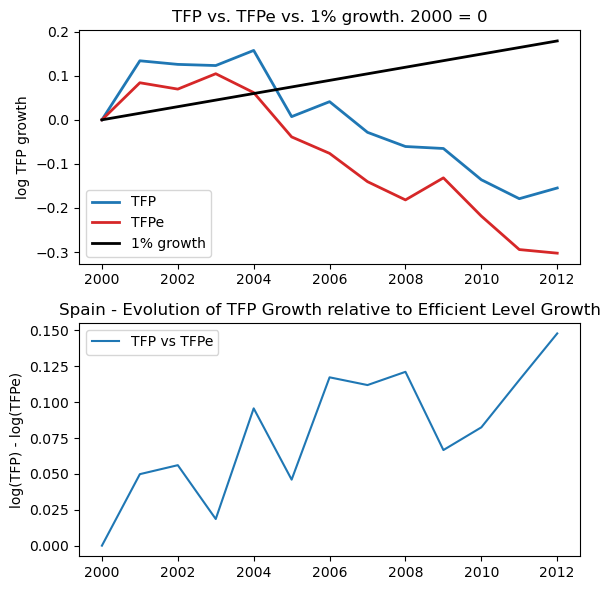

In [16]:
prodplotn = spain.plot_productivity(figsize = (6,6))

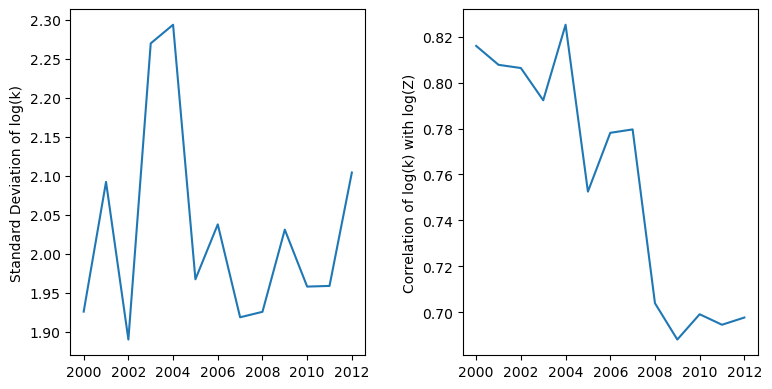

In [17]:
capmoments = spain.plot_capital_tfp_moments(figsize=(8,4))

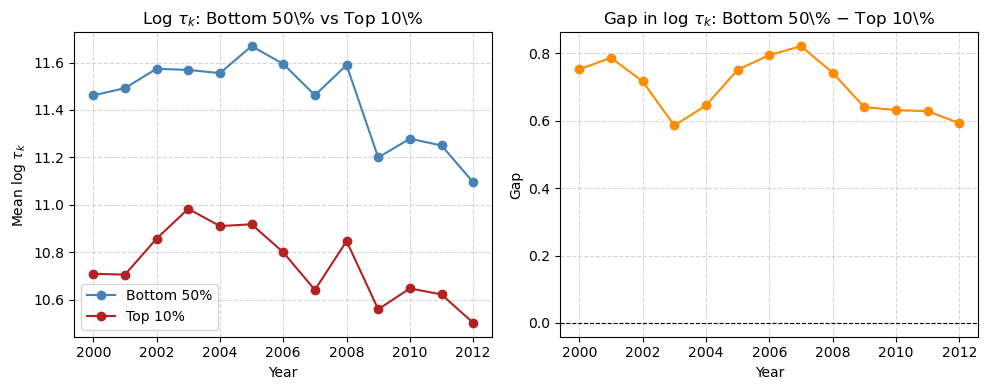

In [21]:
figwedges = spain.plot_capital_wedges()

In [18]:
spain.estimate_all_moments()

Std.dev.(log Z_pow)                     2.460
Std.dev.(log k)                         2.000
Std.dev.(log l)                         1.750
Top 20% Share of l                      0.820
Top 20% Share of k                      0.870
Coef log_Z on capital growth            0.034
Coef log_a on capital growth            0.026
Coef log_k on capital growth           -0.919
Coef log_Z on capital growth t_0 - T    0.036
Coef log_a on capital growth t_0 - T    0.019
Coef log_k on capital growth t_0 - T   -0.634
Coef log_Z on debt growth              -0.012
Coef log_a on debt growth              -0.004
Coef log_k on debt growth              -0.241
Fraction borrowing                      0.700
Corr (log Z, log k)                     0.600
Corr (log Z, log a)                     0.530
Corr (log MRPK, log Z)                  0.300
Corr (log MRPK, log k)                 -0.420
Corr (log MRPK, log a)                 -0.300
dtype: float64

In [ ]:

spain3.estimate_all_moments()

Std.dev.(log Z_pow)                     2.300
Std.dev.(log k)                         1.880
Std.dev.(log l)                         1.690
Top 20% Share of l                      0.810
Top 20% Share of k                      0.880
Coef log_Z on capital growth            0.031
Coef log_a on capital growth            0.034
Coef log_k on capital growth           -0.759
Coef log_Z on capital growth t_0 - T    0.029
Coef log_a on capital growth t_0 - T    0.036
Coef log_k on capital growth t_0 - T   -0.556
Coef log_Z on debt growth               0.003
Coef log_a on debt growth               0.011
Coef log_k on debt growth              -0.098
Fraction borrowing                      0.690
Corr (log Z, log k)                     0.580
Corr (log Z, log a)                     0.500
Corr (log MRPK, log Z)                  0.340
Corr (log MRPK, log k)                 -0.390
Corr (log MRPK, log a)                 -0.300
dtype: float64

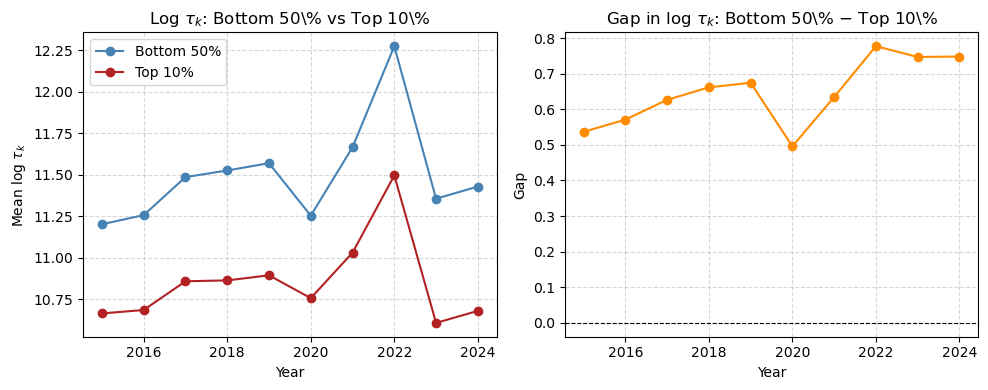

In [22]:
_ = spain3.plot_capital_wedges()